# Employee Attrition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('HR-Employee-Attrition.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.shape

(1470, 35)

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
target = 'Attrition'

binary_features = [
    'Gender',
    'OverTime'
]

ordinal_features = [
    'Education',
    'EnvironmentSatisfaction',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'StockOptionLevel'
]

nominal_features = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus'
]

numerical_features = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

In [9]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
df['Attrition'].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

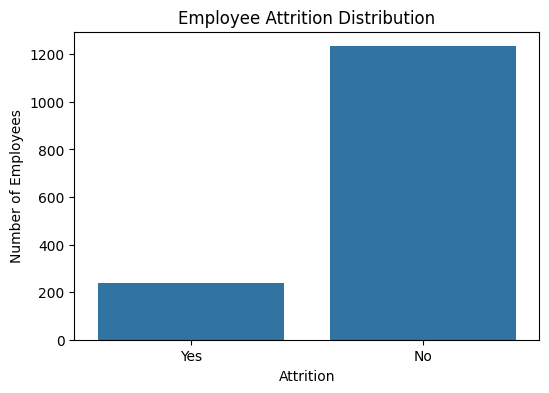

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Attrition')

plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

plt.show()

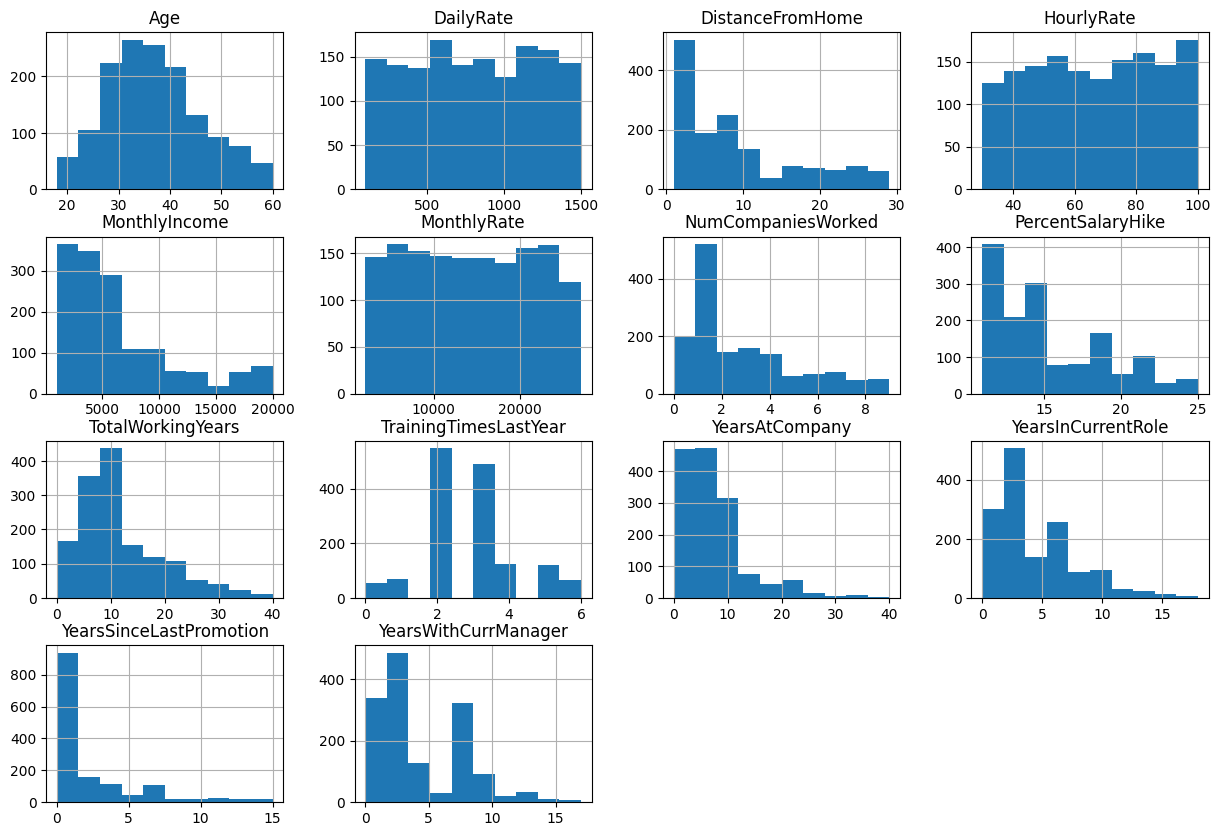

In [12]:
df[numerical_features].hist(figsize=(15,10))

plt.show()

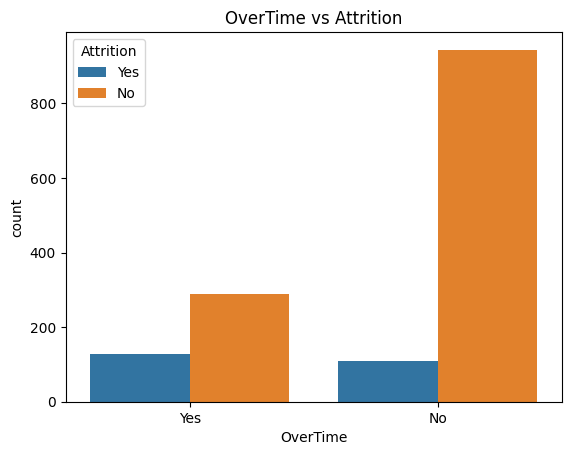

In [13]:
sns.countplot(data=df, x='OverTime', hue='Attrition')

plt.title('OverTime vs Attrition')
plt.show()

In [14]:
df[['EmployeeCount', 'StandardHours', 'Over18']].nunique()

EmployeeCount    1
StandardHours    1
Over18           1
dtype: int64

In [15]:
df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], inplace=True)

In [16]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
binary_mapping = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0,
    'Y': 1,
    'N': 0
}

for col in binary_features:
    X_train[col] = X_train[col].map(binary_mapping)
    X_test[col] = X_test[col].map(binary_mapping)

In [19]:
X_train = pd.get_dummies(X_train, columns=nominal_features, drop_first=True)

X_test = pd.get_dummies(X_test, columns=nominal_features, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [22]:
models = {
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results_default = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    
    preds = model.predict(X_test_scaled)
    
    results_default[name] = accuracy_score(y_test, preds)

results_default

{'KNN': 0.6224489795918368,
 'Naive Bayes': 0.5102040816326531,
 'Logistic Regression': 0.7755102040816326,
 'Decision Tree': 0.7653061224489796,
 'Random Forest': 0.8435374149659864}

In [23]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 9]},
    cv=5
)

knn_grid.fit(X_train_bal, y_train_bal)

print("Best Parameters:", knn_grid.best_params_)

knn_preds = knn_grid.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, knn_preds))

Best Parameters: {'n_neighbors': 3}
Test Accuracy: 0.6836734693877551


In [24]:
nb_grid = GridSearchCV(
    GaussianNB(),
    {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]},
    cv=5
)

nb_grid.fit(X_train_bal, y_train_bal)

print("Best Parameters:", nb_grid.best_params_)

nb_preds = nb_grid.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, nb_preds))

Best Parameters: {'var_smoothing': 1e-09}
Test Accuracy: 0.5102040816326531


In [25]:
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    {'C': [0.01, 0.1, 1, 10]},
    cv=5
)

lr_grid.fit(X_train_bal, y_train_bal)

print("Best Parameters:", lr_grid.best_params_)

lr_preds = lr_grid.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, lr_preds))

Best Parameters: {'C': 0.1}
Test Accuracy: 0.7721088435374149


In [26]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [3, 5, 7, 10, None]},
    cv=5
)

dt_grid.fit(X_train_bal, y_train_bal)

print("Best Parameters:", dt_grid.best_params_)

dt_preds = dt_grid.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, dt_preds))

Best Parameters: {'max_depth': 10}
Test Accuracy: 0.7721088435374149


In [27]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None]
    },
    cv=5
)

rf_grid.fit(X_train_bal, y_train_bal)

print("Best Parameters:", rf_grid.best_params_)

rf_preds = rf_grid.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, rf_preds))

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Test Accuracy: 0.8435374149659864


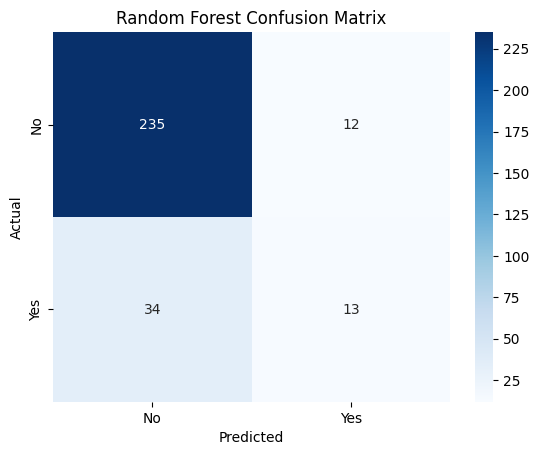

In [28]:
rf_preds = rf_grid.predict(X_test_scaled)

cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [29]:
final_results = {
    "KNN": accuracy_score(y_test, knn_preds),
    "Naive Bayes": accuracy_score(y_test, nb_preds),
    "Logistic Regression": accuracy_score(y_test, lr_preds),
    "Decision Tree": accuracy_score(y_test, dt_preds),
    "Random Forest": accuracy_score(y_test, rf_preds)
}

comparison_df = pd.DataFrame({
    "Default Accuracy": results_default,
    "Tuned Accuracy": final_results
})

comparison_df

,Default Accuracy,Tuned Accuracy
KNN,0.622449,0.683673
Naive Bayes,0.510204,0.510204
Logistic Regression,0.775510,0.772109
Decision Tree,0.765306,0.772109
Random Forest,0.843537,0.843537


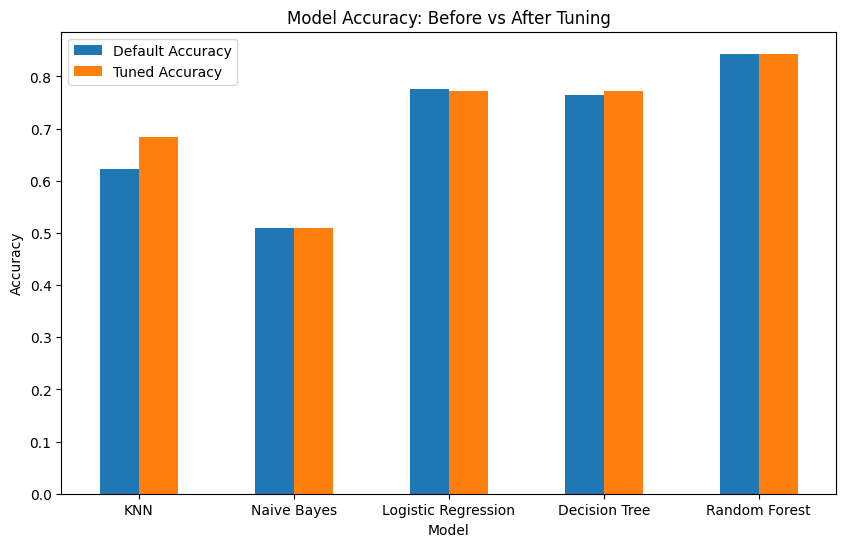

In [30]:
comparison_df.plot(kind="bar", figsize=(10, 6))

plt.title("Model Accuracy: Before vs After Tuning")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend()
plt.show()